## Imports

In [3]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 9/10/24
## Hafta 3
<hr>

### Draw an Image

In [ ]:
plt.imshow(cv2.imread('../DATA/1_ayasofya.jpg'))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


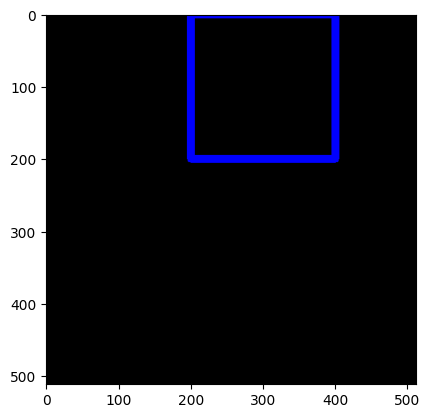

In [15]:
empty = np.zeros(shape=(512, 512, 3))
# np kanalları rgb olarak okur ama cv2 bgr yapar
# dikdörtgen rengini kırmızı olarak ayarladık ama resmi plt ile gösterdiğimizde kırmızı kanalı mavi olarak okur
cv2.rectangle(empty, pt1=(400, 200), pt2=(200, 0), color=(0, 0, 255), thickness=10)
plt.imshow(empty)
# dikdörtgen üst kenarı görüntünün üst tarafına oturur ama kalınlık verdiğimizde kalınlığın yarısı görüntüde gösterilmez

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


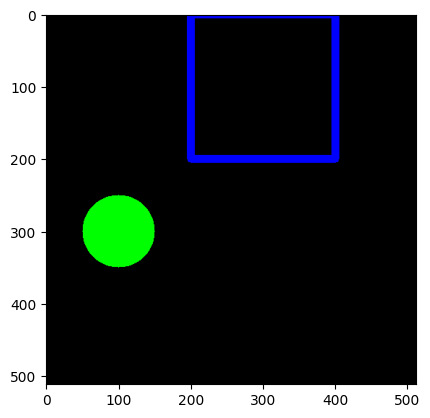

In [20]:
empty2 = empty.copy()
cv2.circle(img=empty2, center=(100, 300), radius=50, color=(0, 255, 0), thickness=-1)
plt.imshow(empty2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


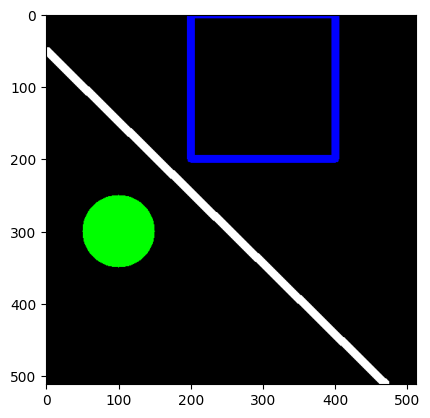

In [19]:
empty3=empty2.copy()
cv2.line(img=empty2, pt1=(0,50), pt2=(470, 512), color=(255, 255, 255), thickness=10)
plt.imshow(empty3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


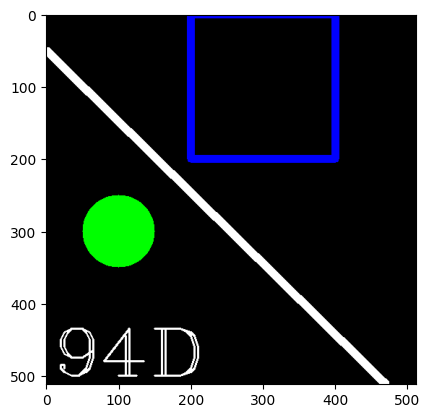

In [25]:
empty4=empty3.copy()
cv2.putText(
    img=empty4,
    text="94D",
    org=(10,500),
    fontFace=cv2.FONT_HERSHEY_COMPLEX_SMALL,
    fontScale=5,
    color=(250, 150, 35),
    thickness=2
)
plt.imshow(empty4)

### Draw using mouse

In [4]:
start_point=(0,0)
is_click = False
def eventCalback(event, x, y, flags, param):
    global start_point
    global blackboard
    global is_click
    if event == cv2.EVENT_LBUTTONDOWN:
        start_point = (x,y)
        is_click = True

    if  (is_click==True and event == cv2.EVENT_MOUSEMOVE) :
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x,y), color=(127,127,0), thickness=-1)
    
    elif (is_click==True and  event == cv2.EVENT_LBUTTONUP):
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x,y), color=(127,127,0), thickness=-1)
        is_click = False

cv2.namedWindow("Track Window")
cv2.setMouseCallback("Track Window", eventCalback)

blackboard = np.zeros(shape=(640, 640, 3), dtype=np.uint8)
blackboard_old = blackboard.copy()

while True:
    cv2.imshow("Track Window", blackboard)

    if cv2.waitKey(10) & 0xFF == 27:
        break

cv2.destroyAllWindows()

In [5]:
start_point = (0, 0)
is_click = False

def event_callback(event, x, y, flags, param):
    global start_point, blackboard, is_click
    if event == cv2.EVENT_LBUTTONDOWN:
        start_point = (x, y)
        is_click = True
    elif is_click and event == cv2.EVENT_MOUSEMOVE:
        blackboard[:] = blackboard_old.copy() # blackboard = blackboard_old yaparsak bellekteki adresi değiştirir ve blackboard_old da değişir
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x, y), color=(127, 127, 0), thickness=-1)
    elif is_click and event == cv2.EVENT_LBUTTONUP:
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x, y), color=(127, 127, 0), thickness=-1)
        is_click = False

cv2.namedWindow("Track Window")
cv2.setMouseCallback("Track Window", event_callback)

blackboard = np.zeros(shape=(640, 640, 3), dtype=np.uint8)
blackboard_old = blackboard.copy()

while True:
    cv2.imshow("Track Window", blackboard)
    if cv2.waitKey(10) & 0xFF == 27:
        break

cv2.destroyAllWindows()


In [5]:
# Eski dikdörtgenleri kaydetme
start_point = (0, 0)
is_click = False
rectangles = []

def event_callback(event, x, y, flags, param):
    global start_point, blackboard, is_click, rectangles
    if event == cv2.EVENT_LBUTTONDOWN:
        start_point = (x, y)
        is_click = True
    elif is_click and event == cv2.EVENT_MOUSEMOVE:
        blackboard[:] = blackboard_old.copy()
        for rect in rectangles:
            cv2.rectangle(blackboard, pt1=rect[0], pt2=rect[1], color=(127, 127, 0), thickness=-1)
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x, y), color=(127, 127, 0), thickness=-1)
    elif is_click and event == cv2.EVENT_LBUTTONUP:
        rectangles.append((start_point, (x, y)))
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x, y), color=(127, 127, 0), thickness=-1)
        is_click = False

cv2.namedWindow("Track Window")
cv2.setMouseCallback("Track Window", event_callback)

blackboard = np.zeros(shape=(640, 640, 3), dtype=np.uint8)
blackboard_old = blackboard.copy()

while True:
    cv2.imshow("Track Window", blackboard)
    if cv2.waitKey(10) & 0xFF == 27:
        break

cv2.destroyAllWindows()

In [4]:
import random

# Eski dikdörtgenleri kaydetme
start_point = (0, 0)
is_click = False
rectangles = []

# her dikdörtgenin farklı bir renk olması için
def random_color():
    return (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))

def event_callback(event, x, y, flags, param):
    global start_point, blackboard, is_click, rectangles
    if event == cv2.EVENT_LBUTTONDOWN:
        start_point = (x, y)
        is_click = True
    elif is_click and event == cv2.EVENT_MOUSEMOVE:
        blackboard[:] = blackboard_old.copy()
        for rect, color in rectangles:
            cv2.rectangle(blackboard, pt1=rect[0], pt2=rect[1], color=color, thickness=-1)
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x, y), color=(127, 127, 0), thickness=-1)
    elif is_click and event == cv2.EVENT_LBUTTONUP:
        color = random_color()
        rectangles.append(((start_point, (x, y)), color))
        cv2.rectangle(blackboard, pt1=start_point, pt2=(x, y), color=color, thickness=-1)
        is_click = False

cv2.namedWindow("Track Window")
cv2.setMouseCallback("Track Window", event_callback)

blackboard = np.zeros(shape=(640, 640, 3), dtype=np.uint8)
blackboard_old = blackboard.copy()

while True:
    cv2.imshow("Track Window", blackboard)
    if cv2.waitKey(10) & 0xFF == 27:
        break

cv2.destroyAllWindows()